
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("All libraries working!")

# Import Libraries

In [175]:
import os

print("Current folder:", os.getcwd())
print("\nFiles:")
print(os.listdir())

Current folder: c:\Users\omtiw\OneDrive\Desktop\Om  project\cognevance task\projec -1-Weather data Analysis\notebook

Files:
['.venv', 'Weather_Analysis.ipynb']


In [176]:
from pathlib import Path

for p in Path("..").rglob("*.zip"):
    print(p)

..\heatwave-dataset-rajasthan-india-2006-2025.zip


# Data Loading

In [177]:
import pandas as pd

df = pd.read_csv("../heatwave-dataset-rajasthan-india-2006-2025.zip")
df.head()

,YEAR,MONTH,DAY,WIND_U10,WIND_V10,MSLP,BLH,GEOP,TEMP2M,TMAX,...,RAIN,SRAD,EVAP,SOILT1,SOILM1,LAI,HEATWAVE,LAT,LON,DISTRICT
0,2006,3,1,-0.223022,-0.440903,101036.375,2020.7317,1671.1079,304.75806,303.54395,...,0.0,3117056,-0.000023,312.75903,0.024887,0.515625,0,25.75,71.5,Barmer
1,2006,3,2,-1.344009,-0.294922,101076.440,2265.7910,1671.1079,306.45337,304.95703,...,0.0,3131200,-0.000024,312.66943,0.024345,0.515625,0,25.75,71.5,Barmer
2,2006,3,3,-0.960449,1.522965,101033.750,3152.6023,1671.1079,307.34863,306.21167,...,0.0,3105536,-0.000024,313.12280,0.023773,0.515625,0,25.75,71.5,Barmer
3,2006,3,4,2.704514,1.733017,100896.940,3146.9475,1671.1079,307.43457,306.70508,...,0.0,3126528,-0.000024,314.12085,0.023147,0.515625,0,25.75,71.5,Barmer
4,2006,3,5,2.717834,2.464432,101014.190,2069.5261,1671.1079,306.19507,304.88306,...,0.0,2776448,-0.000041,312.00806,0.027964,0.515625,0,25.75,71.5,Barmer


In [178]:
df.columns

Index(['YEAR', 'MONTH', 'DAY', 'WIND_U10', 'WIND_V10', 'MSLP', 'BLH', 'GEOP',
       'TEMP2M', 'TMAX', 'TMIN', 'DEW2M', 'CLOUD', 'RAIN', 'SRAD', 'EVAP',
       'SOILT1', 'SOILM1', 'LAI', 'HEATWAVE', 'LAT', 'LON', 'DISTRICT'],
      dtype='object')

In [179]:
df["TEMP_C"] = df["TEMP2M"] - 273.15

In [180]:
df["TEMP_C"].head()

0    31.60806
1    33.30337
2    34.19863
3    34.28457
4    33.04507
Name: TEMP_C, dtype: float64

In [181]:
print("Maximum Temperature:")
print(df["TEMP_C"].max())
#  Analysis 2:- Maximum Temperature 

Maximum Temperature:
48.69010000000003


In [182]:
print("Minimum Temperature:")
print(df["TEMP_C"].min())
#  Analysis 3:- Minimum Temperature

Minimum Temperature:
15.18300000000005


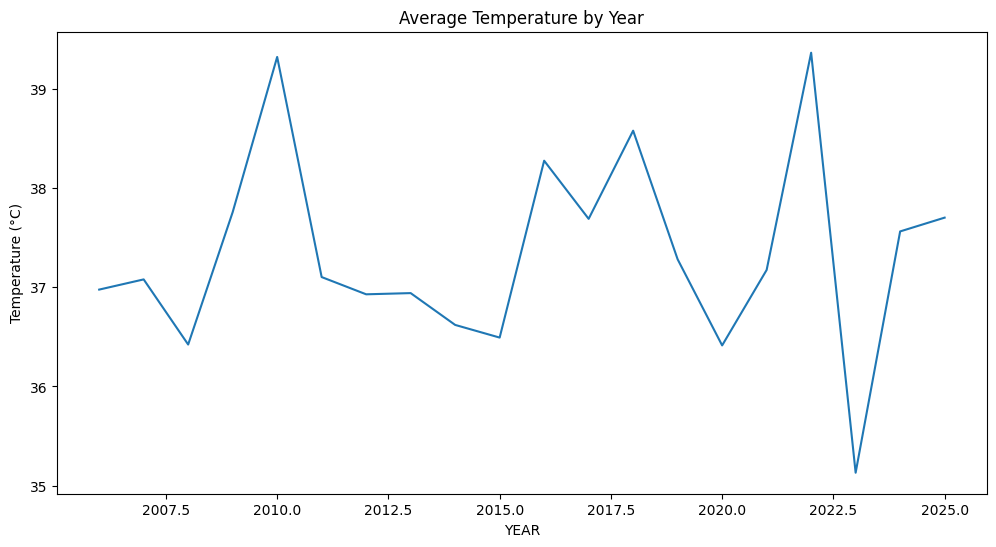

In [183]:
yearly_temp = df.groupby("YEAR")["TEMP_C"].mean()

import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
yearly_temp.plot()
plt.title("Average Temperature by Year")
plt.ylabel("Temperature (°C)")
plt.show()
# Analysis 4:- Average Temperature by Year

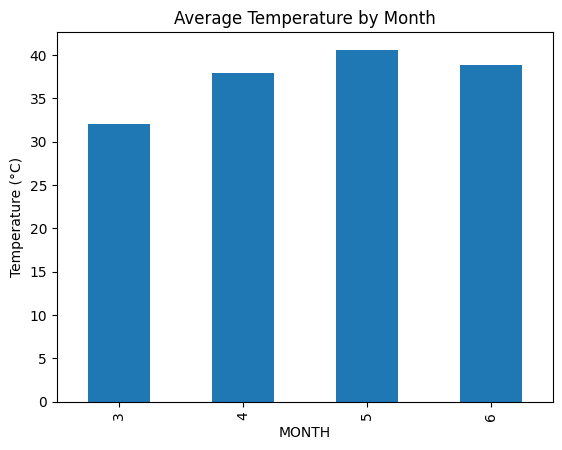

In [184]:
monthly_temp = df.groupby("MONTH")["TEMP_C"].mean()

monthly_temp.plot(kind="bar")
plt.title("Average Temperature by Month")
plt.ylabel("Temperature (°C)")
plt.show()
# Analysis 5:- Average Temperature by Month

In [185]:
df.groupby("YEAR")["TEMP_C"].mean().sort_values(ascending=False).head()
# Analysis 6:- Top 5 Hottest Years

YEAR
2022    39.362025
2010    39.319469
2018    38.576484
2016    38.273995
2009    37.755508
Name: TEMP_C, dtype: float64

In [186]:
df.groupby("MONTH")["TEMP_C"].mean().sort_values(ascending=False)
# Analysis 7:- Hottest Month

MONTH
5    40.593988
6    38.815910
4    37.918775
3    32.095644
Name: TEMP_C, dtype: float64

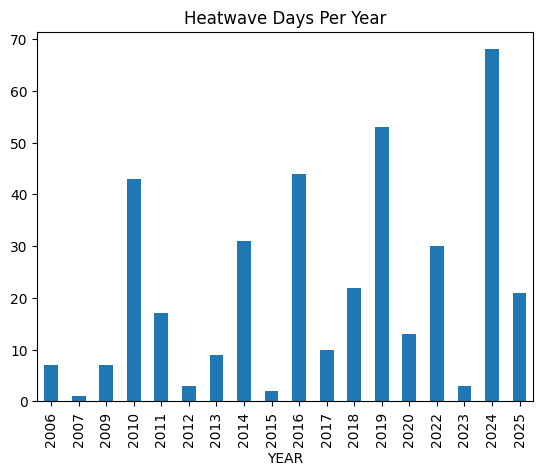

In [187]:
heatwave = df[df["TEMP_C"] > 45]
len(heatwave)
heatwave.groupby("YEAR").size()
heatwave.groupby("YEAR").size().plot(kind="bar")
plt.title("Heatwave Days Per Year")
plt.show()
#Analysis 8:- Heatwave Days Per Year

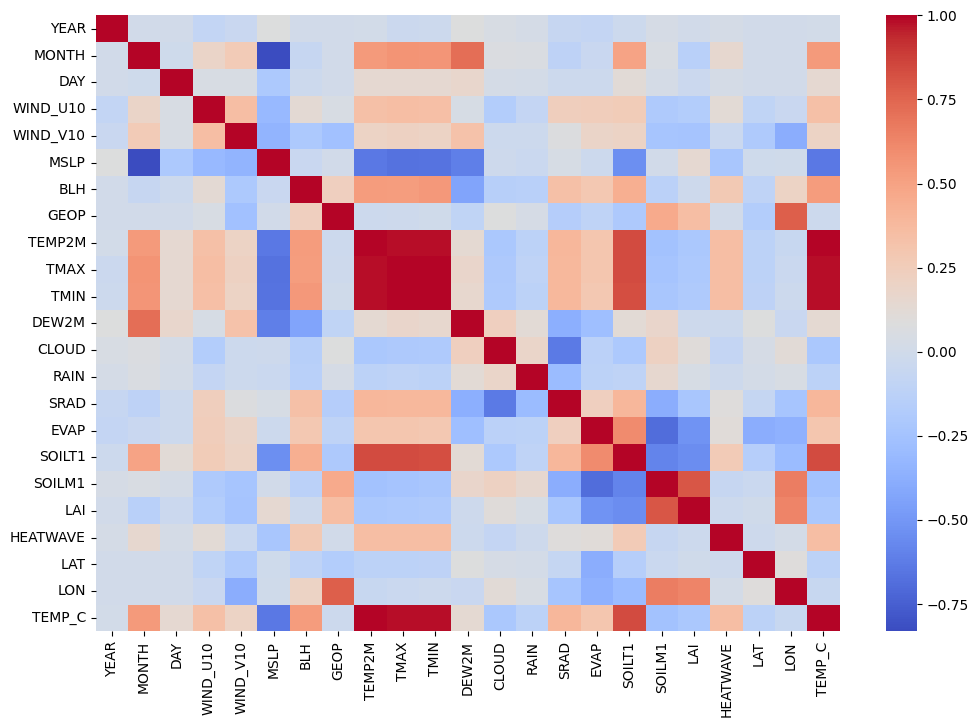

In [188]:
import seaborn as sns

plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True),
            annot=False,
            cmap="coolwarm")
plt.show()
# Analysis 9:- Correlation Heatmap

In [189]:
df.nlargest(10, "TEMP_C")[["YEAR","MONTH","DAY","TEMP_C"]]
# Analysis 10:- Top 10 Hottest Days

,YEAR,MONTH,DAY,TEMP_C
12043,2024,5,27,48.69010
2283,2024,5,27,48.52212
4724,2024,5,28,48.50894
4722,2024,5,26,48.30264
11059,2016,5,19,48.30240
16923,2024,5,27,48.27017
3739,2016,5,19,48.22036
3740,2016,5,20,47.97134
1299,2016,5,19,47.81410
11058,2016,5,18,47.79970
